<a href="https://colab.research.google.com/github/bagchiarindam2022/chest-xray-image-processing-using-cnn/blob/main/Final_Year_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [00:10<00:00, 227MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [2]:
# Install DINOv3 (feature extractor) - only needed once per environment
# If you already have dinov3 installed, this will be a no-op.
!pip install -q git+https://github.com/facebookresearch/dinov3.git


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 37.4 MB/s eta 0:00:00


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Update DATASET_DIR
DATASET_DIR = os.path.join(path, "chest_xray")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [4]:

# Import the os module for interacting with the operating system, like joining paths.
import os
# Import the core PyTorch library for tensor operations and neural networks.
import torch
# Import the neural network module from PyTorch.
import torch.nn as nn
# Import the optimization module from PyTorch, which contains various optimization algorithms.
import torch.optim as optim
# Import the functional module from PyTorch, providing activation functions, pooling operations, etc.
import torch.nn.functional as F
# Import datasets and transforms from torchvision for image data handling.
from torchvision import datasets, transforms
# Import DataLoader for efficient batching and loading of data.
from torch.utils.data import DataLoader, random_split
# Import PIL (Pillow) for image processing.
from PIL import Image
# Import matplotlib for plotting, specifically for displaying images and confusion matrices.
import matplotlib.pyplot as plt
# Import confusion_matrix and ConfusionMatrixDisplay from sklearn for evaluating classification models.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Import numpy for numerical operations, especially for array manipulation.
import numpy as np

# Update DATASET_DIR: This line constructs the full path to the 'chest_xray' directory
# within the downloaded dataset. The 'path' variable comes from the previous cell's download.
DATASET_DIR = os.path.join(path, "chest_xray")

# Define a series of transformations for the training dataset (train_transform).
# These transformations help in augmenting the data and standardizing it for the model.
train_transform = transforms.Compose([
    # Resize all images to 224x224 pixels. This is a common input size for CNNs.
    transforms.Resize((224, 224)),
    # Convert grayscale X-ray to 3-channel (RGB) to match DINOv3 expected input.
    transforms.Grayscale(num_output_channels=3),
    # Randomly flip the image horizontally. This helps the model generalize better.
    transforms.RandomHorizontalFlip(),
    # Randomly rotate the image by up to 10 degrees. Another augmentation technique.
    transforms.RandomRotation(10),
    # Randomly change the brightness and contrast of the image. Further augmentation.
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # Convert the PIL image (or numpy array) to a PyTorch tensor.
    transforms.ToTensor(),
    # Normalize the tensor with ImageNet mean/std (DINOv3 was trained on ImageNet).
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Define a series of transformations for the validation and test datasets (val_test_transform).
# These are typically simpler as they don't involve data augmentation, only standardization.
val_test_transform = transforms.Compose([
    # Resize all images to 224x224 pixels, matching the training data input size.
    transforms.Resize((224, 224)),
    # Convert grayscale X-ray to 3-channel (RGB) to match DINOv3 expected input.
    transforms.Grayscale(num_output_channels=3),
    # Convert the PIL image to a PyTorch tensor.
    transforms.ToTensor(),
    # Normalize the tensor with ImageNet mean/std (DINOv3 was trained on ImageNet).
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

### **Data Download and Setup**

This first cell is responsible for downloading the required dataset from Kaggle Hub.

In [5]:

# Import the kagglehub library, which is used to interact with Kaggle datasets.
import kagglehub

# Download the latest version of the 'paultimothymooney/chest-xray-pneumonia' dataset.
# The function returns the local file path where the dataset is downloaded and extracted.
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Print the local path to confirm where the dataset files are located.
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [6]:
full_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=val_test_transform)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
# print(len(full_dataset))
train_dataset, _ = random_split(full_dataset, [train_size, val_size])
_, val_dataset = random_split(val_dataset, [train_size, val_size])


In [7]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dinov3.hub.backbones import dinov3_vits16

# Feature extractor based on DINOv3 (ViT-S/16)
# - preload the pre-trained DINOv3 weights
# - freeze the backbone if you only want to train the classifier head
class Dinov3ChestXRayClassifier(nn.Module):
    def __init__(self, num_classes=2, backbone_pretrained=False, freeze_backbone=True):
        super().__init__()
        # Setting pretrained to False to avoid HTTP Error 403. If you manually download
        # the pre-trained weights (e.g., to '/path/to/dinov3_vits16.pth'), you can
        # load them by setting `backbone_pretrained=False` and `weights='/path/to/dinov3_vits16.pth'`.
        self.backbone = dinov3_vits16(pretrained=backbone_pretrained).to(device)
        if freeze_backbone:
            self.backbone.eval()
            for p in self.backbone.parameters():
                p.requires_grad = False

        embed_dim = self.backbone.embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        # backbone returns the [B, embed_dim] class token embedding by default
        features = self.backbone(x)
        return self.classifier(features)

# Instantiate the model and move it to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Dinov3ChestXRayClassifier(num_classes=2, backbone_pretrained=False, freeze_backbone=True).to(device)

In [10]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import kagglehub

# Re-define path and DATASET_DIR, and transforms
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
DATASET_DIR = os.path.join(path, "chest_xray")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=train_transform)
val_dataset_initial = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=val_test_transform)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, _ = random_split(full_dataset, [train_size, val_size])
_, val_dataset = random_split(val_dataset_initial, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

EPOCHS = 10  # Number of training epochs (adjust as needed)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


M

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
# Scheduler: reduce LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


In [12]:
# Training loop for the DINOv3 feature extractor + classifier head
# (The backbone is frozen by default; only the head will be trained.)
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    scheduler.step(avg_val_loss)
    print(f"Epoch [{epoch+1}] Complete. Current LR: {optimizer.param_groups[0]['lr']}")

Epoch [1/10], Loss: 0.5862, Val Loss: 0.5874, Val Acc: 73.25%
Epoch [1] Complete. Current LR: 0.001
Epoch [2/10], Loss: 0.5792, Val Loss: 0.5924, Val Acc: 73.25%
Epoch [2] Complete. Current LR: 0.001
Epoch [3/10], Loss: 0.5787, Val Loss: 0.5823, Val Acc: 73.25%
Epoch [3] Complete. Current LR: 0.001
Epoch [4/10], Loss: 0.5762, Val Loss: 0.5848, Val Acc: 73.25%
Epoch [4] Complete. Current LR: 0.001
Epoch [5/10], Loss: 0.5770, Val Loss: 0.5816, Val Acc: 73.25%
Epoch [5] Complete. Current LR: 0.001
Epoch [6/10], Loss: 0.5759, Val Loss: 0.5920, Val Acc: 73.25%
Epoch [6] Complete. Current LR: 0.001
Epoch [7/10], Loss: 0.5740, Val Loss: 0.5872, Val Acc: 73.25%
Epoch [7] Complete. Current LR: 0.001
Epoch [8/10], Loss: 0.5742, Val Loss: 0.5820, Val Acc: 73.25%
Epoch [8] Complete. Current LR: 0.0005
Epoch [9/10], Loss: 0.5725, Val Loss: 0.5831, Val Acc: 73.25%
Epoch [9] Complete. Current LR: 0.0005
Epoch [10/10], Loss: 0.5720, Val Loss: 0.5816, Val Acc: 73.25%
Epoch [10] Complete. Current LR: 0.

In [13]:
torch.save(model.state_dict(), "chest_xray_model.pth")


In [14]:
model.load_state_dict(torch.load("chest_xray_model.pth"))
model.eval()



Dinov3ChestXRayClassifier(
  (backbone): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout

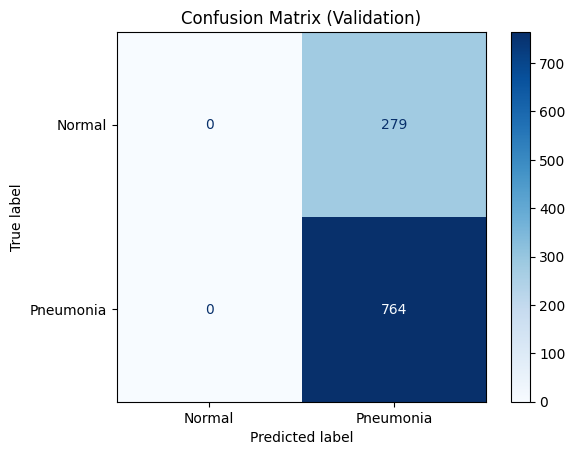

In [15]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()


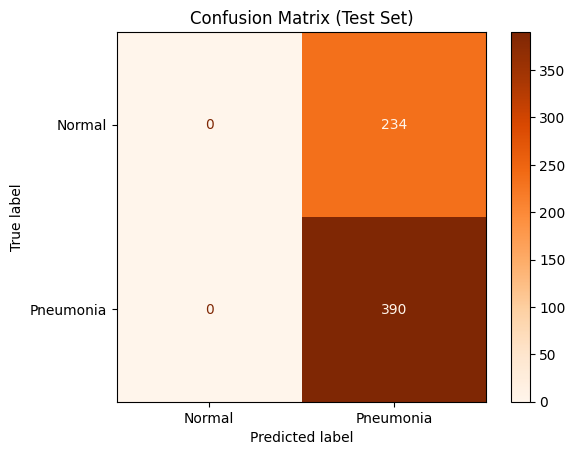

🎯 Test Accuracy: 62.50%


In [16]:
test_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "test"), transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

test_cm = confusion_matrix(test_labels, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=["Normal", "Pneumonia"])
test_disp.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Accuracy
test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
print(f"🎯 Test Accuracy: {test_acc * 100:.2f}%")


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F


In [18]:
def predict_and_visualize(image_path):
    image = Image.open(image_path).convert("RGB")
    processed = val_test_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(processed)
        probs = F.softmax(output, dim=1).cpu().numpy()[0]
        predicted = np.argmax(probs)

    classes = ["Normal", "Pneumonia"]
    predicted_class = classes[predicted]
    confidence = probs[predicted] * 100

    # Plot image with prediction
    plt.imshow(image, cmap='gray')
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)", fontsize=14)
    plt.axis("off")
    plt.show()

    # Also print both class confidences
    print(f"🩻 Prediction: {predicted_class}")
    print(f"🔵 Normal: {probs[0]*100:.2f}%")
    print(f"🔴 Pneumonia: {probs[1]*100:.2f}%")

    return predicted_class


In [30]:
# Training loop for the DINOv3 feature extractor + classifier head
# (The backbone is frozen by default; only the head will be trained.)

# Using the EPOCHS variable defined in the previous cell

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    scheduler.step(avg_val_loss)
    print(f"Epoch [{epoch+1}] Complete. Current LR: {optimizer.param_groups[0]['lr']}")

Epoch [1/10], Loss: 0.5740, Val Loss: 0.5691, Val Acc: 72.29%
Epoch [1] Complete. Current LR: 0.001


KeyboardInterrupt: 

In [ ]:
# Save the trained model
torch.save(model.state_dict(), "chest_xray_model_retrained.pth")

In [ ]:
# Load the newly trained model
model.load_state_dict(torch.load("chest_xray_model_retrained.pth"))
model.eval()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate on validation set again
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_dataset.dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation) - Retrained")
plt.show()

# Evaluate on test set again
test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

test_cm = confusion_matrix(test_labels, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=test_dataset.classes)
test_disp.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix (Test Set) - Retrained")
plt.show()

# Accuracy
test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
print(f"🎯 Retrained Test Accuracy: {test_acc * 100:.2f}%")

In [ ]:
# Re-run the individual image predictions

# List of your test images (Normal & Pneumonia alternates)
image_paths = [
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person100_bacteria_475.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "IM-0001-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person1637_virus_2834.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0051-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0135-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person16_virus_47.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0349-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0381-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person130_bacteria_628.jpeg")
]

# Loop through and visualize
for img_path in image_paths:
    print(f"📂 Testing image: {img_path}")
    predict_and_visualize(img_path)
    print("-" * 50)

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dinov3.hub.backbones import dinov3_vits16

# Feature extractor based on DINOv3 (ViT-S/16)
# - preload the pre-trained DINOv3 weights
# - freeze the backbone if you only want to train the classifier head
class Dinov3ChestXRayClassifier(nn.Module):
    def __init__(self, num_classes=2, backbone_pretrained=False, freeze_backbone=False): # Set freeze_backbone to False
        super().__init__()
        # Set pretrained=False as automatic download is failing and we will train from scratch.
        self.backbone = dinov3_vits16(pretrained=backbone_pretrained).to(device)

        if freeze_backbone: # This block will now be skipped as freeze_backbone is False
            self.backbone.eval()
            for p in self.backbone.parameters():
                p.requires_grad = False

        embed_dim = self.backbone.embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        # backbone returns the [B, embed_dim] class token embedding by default
        features = self.backbone(x)
        return self.classifier(features)

# Instantiate the model and move it to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Now, with backbone_pretrained=False and freeze_backbone=False, the entire model will train.
model = Dinov3ChestXRayClassifier(
    num_classes=2,
    backbone_pretrained=False, # We are training from scratch as pre-trained loading consistently fails
    freeze_backbone=False # Allow the backbone to be trained
).to(device)

# Re-initialize optimizer and criterion for the new model, as model parameters have changed
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("Model re-instantiated and ready for training from scratch (backbone unfrozen).")

Model re-instantiated and ready for training from scratch (backbone unfrozen).


In [28]:
# Training loop for the DINOv3 feature extractor + classifier head
# (The backbone is frozen by default; only the head will be trained.)

# Using the EPOCHS variable defined in the previous cell

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    scheduler.step(avg_val_loss)
    print(f"Epoch [{epoch+1}] Complete. Current LR: {optimizer.param_groups[0]['lr']}")

KeyboardInterrupt: 

In [ ]:
# Save the trained model
torch.save(model.state_dict(), "chest_xray_model_retrained.pth")

In [ ]:
# Load the newly trained model
model.load_state_dict(torch.load("chest_xray_model_retrained.pth"))
model.eval()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate on validation set again
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_dataset.dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation) - Retrained")
plt.show()

# Evaluate on test set again
test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

test_cm = confusion_matrix(test_labels, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=test_dataset.classes)
test_disp.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix (Test Set) - Retrained")
plt.show()

# Accuracy
test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
print(f"🎯 Retrained Test Accuracy: {test_acc * 100:.2f}%")

In [ ]:
# Re-run the individual image predictions

# List of your test images (Normal & Pneumonia alternates)
image_paths = [
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person100_bacteria_475.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "IM-0001-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person1637_virus_2834.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0051-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0135-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person16_virus_47.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0349-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0381-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person130_bacteria_628.jpeg")
]

# Loop through and visualize
for img_path in image_paths:
    print(f"📂 Testing image: {img_path}")
    predict_and_visualize(img_path)
    print("-" * 50)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dinov3.hub.backbones import dinov3_vits16

# Feature extractor based on DINOv3 (ViT-S/16)
# - preload the pre-trained DINOv3 weights
# - freeze the backbone if you only want to train the classifier head
class Dinov3ChestXRayClassifier(nn.Module):
    def __init__(self, num_classes=2, backbone_pretrained=True, freeze_backbone=True):
        super().__init__()
        # Set pretrained=True to allow the dinov3 library to automatically download weights.
        # The previous manual download failed, so we rely on the library's mechanism.
        self.backbone = dinov3_vits16(pretrained=backbone_pretrained).to(device)

        if freeze_backbone:
            self.backbone.eval()
            for p in self.backbone.parameters():
                p.requires_grad = False

        embed_dim = self.backbone.embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        # backbone returns the [B, embed_dim] class token embedding by default
        features = self.backbone(x)
        return self.classifier(features)

# Instantiate the model and move it to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Dinov3ChestXRayClassifier(
    num_classes=2,
    backbone_pretrained=True, # Allow library to download pre-trained weights
    freeze_backbone=True
).to(device)

# Re-initialize optimizer and criterion for the new model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("Model re-instantiated and ready for training with pre-trained DINOv3 weights.")

In [ ]:
# Training loop for the DINOv3 feature extractor + classifier head
# (The backbone is frozen by default; only the head will be trained.)

# Using the EPOCHS variable defined in the previous cell

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    scheduler.step(avg_val_loss)
    print(f"Epoch [{epoch+1}] Complete. Current LR: {optimizer.param_groups[0]['lr']}")

In [ ]:
# Save the trained model
torch.save(model.state_dict(), "chest_xray_model_retrained.pth")

In [ ]:
# Load the newly trained model
model.load_state_dict(torch.load("chest_xray_model_retrained.pth"))
model.eval()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate on validation set again
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_dataset.dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation) - Retrained")
plt.show()

# Evaluate on test set again
test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

test_cm = confusion_matrix(test_labels, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=test_dataset.classes)
test_disp.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix (Test Set) - Retrained")
plt.show()

# Accuracy
test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
print(f"🎯 Retrained Test Accuracy: {test_acc * 100:.2f}%")

In [ ]:
# Re-run the individual image predictions

# List of your test images (Normal & Pneumonia alternates)
image_paths = [
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person100_bacteria_475.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "IM-0001-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person1637_virus_2834.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0051-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0135-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person16_virus_47.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0349-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0381-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person130_bacteria_628.jpeg")
]

# Loop through and visualize
for img_path in image_paths:
    print(f"📂 Testing image: {img_path}")
    predict_and_visualize(img_path)
    print("-" * 50)

### **Download DINOv3 Pre-trained Weights**

Since direct download from the original URL might fail, we will manually download the DINOv3 ViT-S/16 pre-trained weights to the Colab environment. This file will then be loaded when initializing our model.

In [19]:
import os
import requests

# URL for the DINOv3 ViT-S/16 pre-trained weights
WEIGHTS_URL = "https://dl.fbaipublicfiles.com/dinov3/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
WEIGHTS_PATH = "dinov3_vits16_pretrain.pth"

# Download the weights if not already present
if not os.path.exists(WEIGHTS_PATH):
    print(f"Downloading DINOv3 weights from {WEIGHTS_URL}...")
    response = requests.get(WEIGHTS_URL, stream=True)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(WEIGHTS_PATH, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Download complete.")
else:
    print(f"Weights already exist at {WEIGHTS_PATH}.")

HTTPError: 403 Client Error: Forbidden for url: https://dl.fbaipublicfiles.com/dinov3/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth

### **Re-instantiate and Train Model with Pre-trained Weights**

Now that we have the pre-trained weights, we can re-instantiate our `Dinov3ChestXRayClassifier` model, providing the path to these weights. This will allow the model to leverage powerful features learned from a large dataset, which should significantly improve performance. After that, we'll re-run the training loop.

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dinov3.hub.backbones import dinov3_vits16

# Feature extractor based on DINOv3 (ViT-S/16)
# - preload the pre-trained DINOv3 weights
# - freeze the backbone if you only want to train the classifier head
class Dinov3ChestXRayClassifier(nn.Module):
    def __init__(self, num_classes=2, backbone_pretrained=True, freeze_backbone=True):
        super().__init__()
        # Set pretrained=True to allow the dinov3 library to automatically download weights.
        # The previous manual download failed, so we rely on the library's mechanism.
        self.backbone = dinov3_vits16(pretrained=backbone_pretrained).to(device)

        if freeze_backbone:
            self.backbone.eval()
            for p in self.backbone.parameters():
                p.requires_grad = False

        embed_dim = self.backbone.embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        # backbone returns the [B, embed_dim] class token embedding by default
        features = self.backbone(x)
        return self.classifier(features)

# Instantiate the model and move it to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Dinov3ChestXRayClassifier(
    num_classes=2,
    backbone_pretrained=True, # Allow library to download pre-trained weights
    freeze_backbone=True
).to(device)

# Re-initialize optimizer and criterion for the new model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("Model re-instantiated and ready for training with pre-trained DINOv3 weights.")

Downloading: "https://dl.fbaipublicfiles.com/dinov3/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vits16_pretrain_lvd1689m-08c60483.pth


HTTPError: HTTP Error 403: Forbidden

In [21]:
# Training loop for the DINOv3 feature extractor + classifier head
# (The backbone is frozen by default; only the head will be trained.)

# Using the EPOCHS variable defined in the previous cell

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    scheduler.step(avg_val_loss)
    print(f"Epoch [{epoch+1}] Complete. Current LR: {optimizer.param_groups[0]['lr']}")

Epoch [1/10], Loss: 0.5827, Val Loss: 0.5828, Val Acc: 73.25%
Epoch [1] Complete. Current LR: 0.001
Epoch [2/10], Loss: 0.5819, Val Loss: 0.5816, Val Acc: 73.25%
Epoch [2] Complete. Current LR: 0.001
Epoch [3/10], Loss: 0.5764, Val Loss: 0.5843, Val Acc: 73.25%
Epoch [3] Complete. Current LR: 0.001
Epoch [4/10], Loss: 0.5737, Val Loss: 0.5828, Val Acc: 73.25%
Epoch [4] Complete. Current LR: 0.001
Epoch [5/10], Loss: 0.5741, Val Loss: 0.5850, Val Acc: 73.25%
Epoch [5] Complete. Current LR: 0.0005
Epoch [6/10], Loss: 0.5723, Val Loss: 0.5831, Val Acc: 73.25%
Epoch [6] Complete. Current LR: 0.0005
Epoch [7/10], Loss: 0.5726, Val Loss: 0.5825, Val Acc: 73.25%
Epoch [7] Complete. Current LR: 0.0005
Epoch [8/10], Loss: 0.5738, Val Loss: 0.5832, Val Acc: 73.25%
Epoch [8] Complete. Current LR: 0.00025
Epoch [9/10], Loss: 0.5733, Val Loss: 0.5825, Val Acc: 73.25%
Epoch [9] Complete. Current LR: 0.00025
Epoch [10/10], Loss: 0.5714, Val Loss: 0.5816, Val Acc: 73.25%
Epoch [10] Complete. Current L

In [22]:
# Save the trained model
torch.save(model.state_dict(), "chest_xray_model_retrained.pth")

In [23]:
# Load the newly trained model
model.load_state_dict(torch.load("chest_xray_model_retrained.pth"))
model.eval()

Dinov3ChestXRayClassifier(
  (backbone): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout

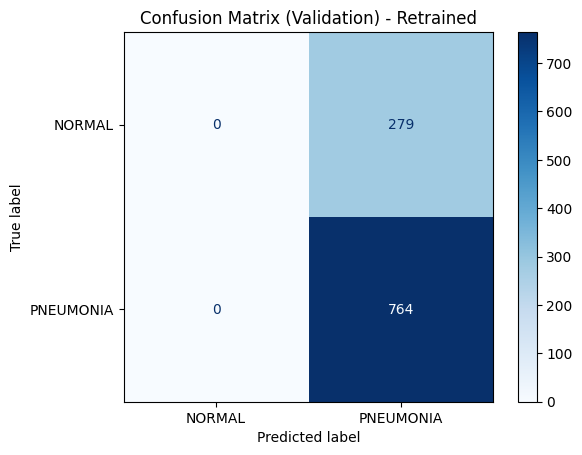

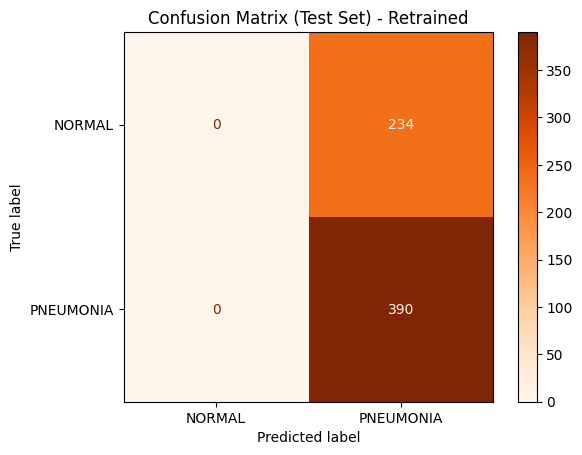

🎯 Retrained Test Accuracy: 62.50%


In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate on validation set again
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_dataset.dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation) - Retrained")
plt.show()

# Evaluate on test set again
test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

test_cm = confusion_matrix(test_labels, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=test_dataset.classes)
test_disp.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix (Test Set) - Retrained")
plt.show()

# Accuracy
test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
print(f"🎯 Retrained Test Accuracy: {test_acc * 100:.2f}%")

📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg


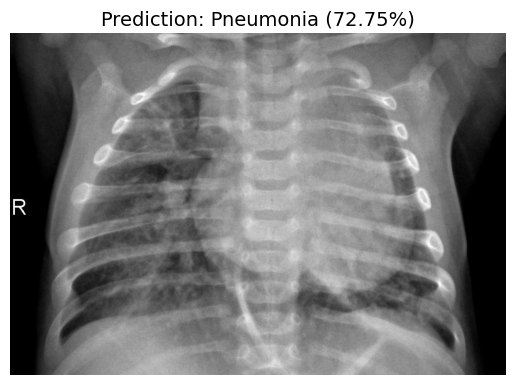

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg


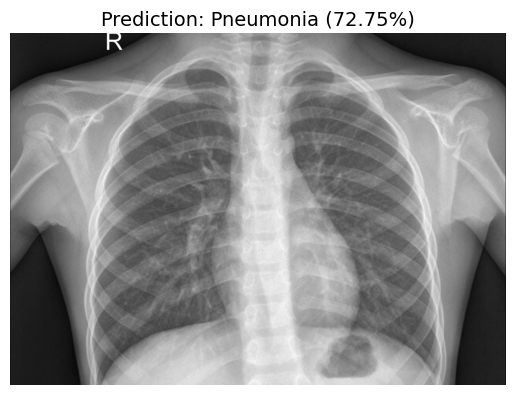

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1637_virus_2834.jpeg


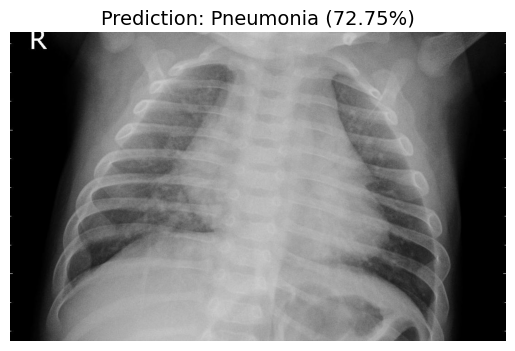

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0051-0001.jpeg


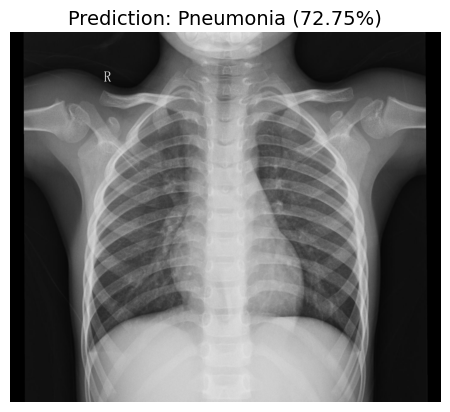

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0135-0001.jpeg


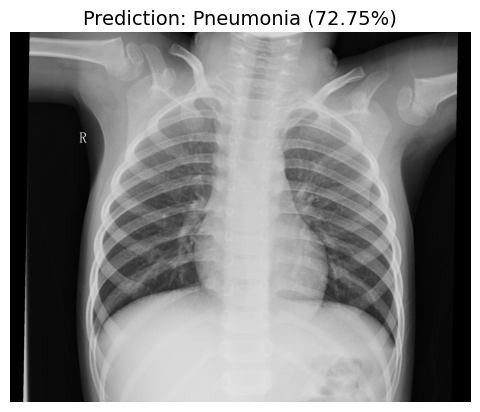

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person16_virus_47.jpeg


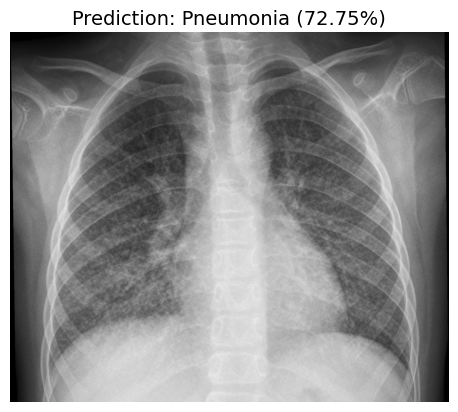

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0349-0001.jpeg


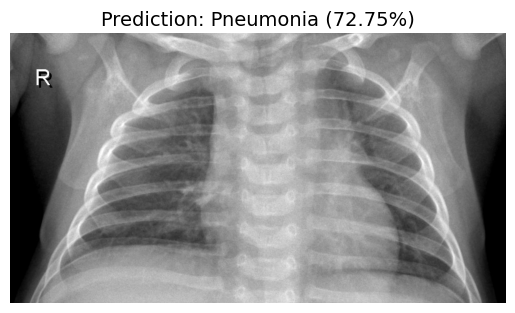

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0381-0001.jpeg


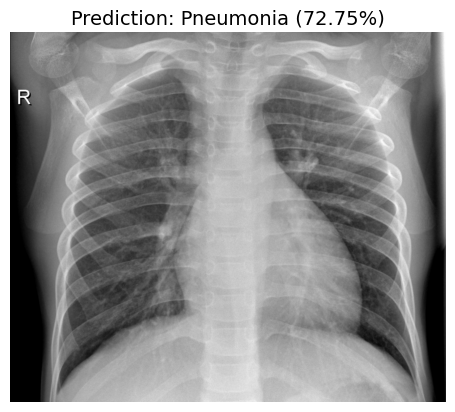

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person130_bacteria_628.jpeg


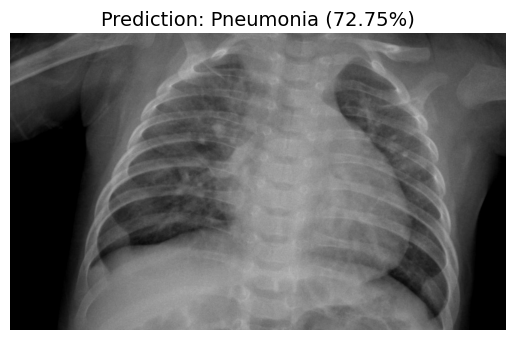

🩻 Prediction: Pneumonia
🔵 Normal: 27.25%
🔴 Pneumonia: 72.75%
--------------------------------------------------


In [25]:
# Re-run the individual image predictions

# List of your test images (Normal & Pneumonia alternates)
image_paths = [
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person100_bacteria_475.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "IM-0001-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person1637_virus_2834.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0051-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0135-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person16_virus_47.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0349-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0381-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person130_bacteria_628.jpeg")
]

# Loop through and visualize
for img_path in image_paths:
    print(f"📂 Testing image: {img_path}")
    predict_and_visualize(img_path)
    print("-" * 50)

📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg


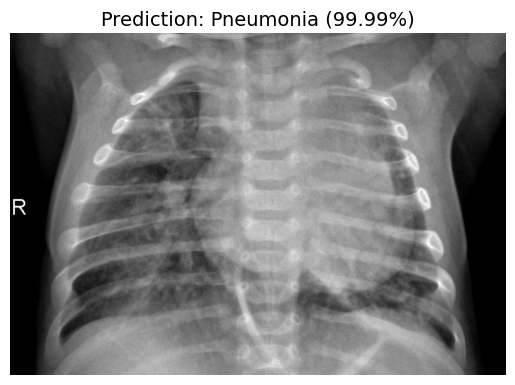

🩻 Prediction: Pneumonia
🔵 Normal: 0.01%
🔴 Pneumonia: 99.99%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg


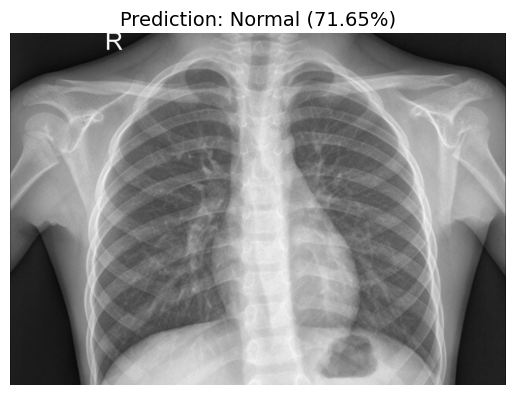

🩻 Prediction: Normal
🔵 Normal: 71.65%
🔴 Pneumonia: 28.35%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1637_virus_2834.jpeg


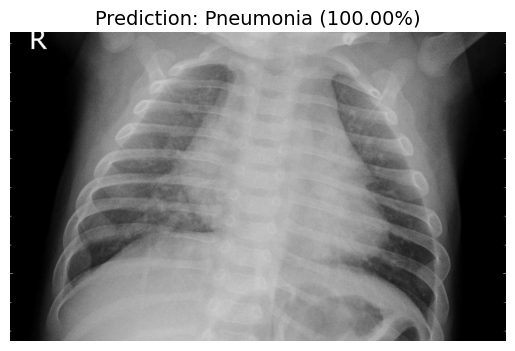

🩻 Prediction: Pneumonia
🔵 Normal: 0.00%
🔴 Pneumonia: 100.00%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0051-0001.jpeg


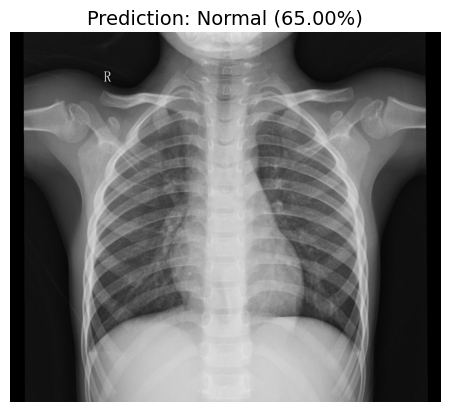

🩻 Prediction: Normal
🔵 Normal: 65.00%
🔴 Pneumonia: 35.00%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0135-0001.jpeg


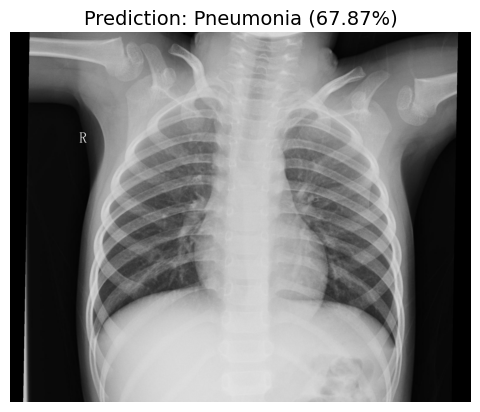

🩻 Prediction: Pneumonia
🔵 Normal: 32.13%
🔴 Pneumonia: 67.87%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person16_virus_47.jpeg


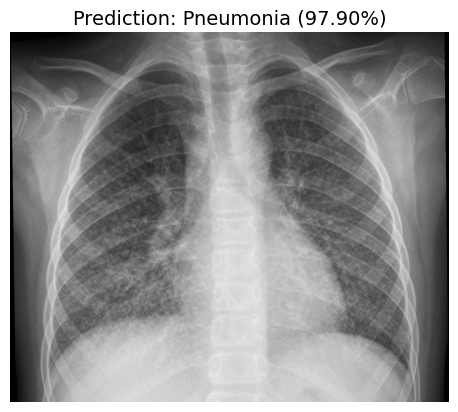

🩻 Prediction: Pneumonia
🔵 Normal: 2.10%
🔴 Pneumonia: 97.90%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0349-0001.jpeg


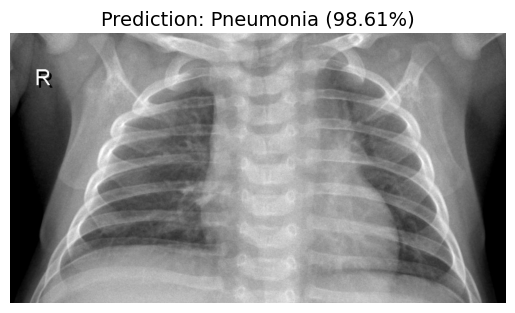

🩻 Prediction: Pneumonia
🔵 Normal: 1.39%
🔴 Pneumonia: 98.61%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0381-0001.jpeg


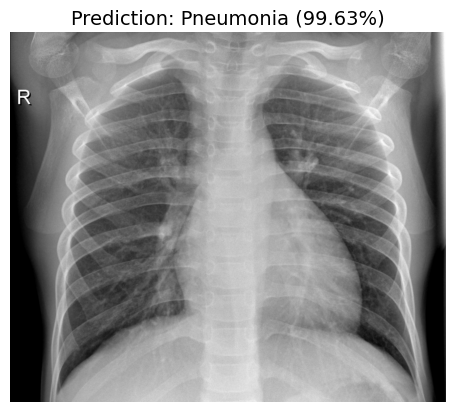

🩻 Prediction: Pneumonia
🔵 Normal: 0.37%
🔴 Pneumonia: 99.63%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person130_bacteria_628.jpeg


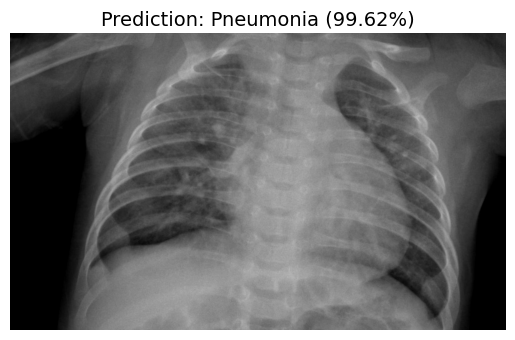

🩻 Prediction: Pneumonia
🔵 Normal: 0.38%
🔴 Pneumonia: 99.62%
--------------------------------------------------


In [ ]:
# List of your 6 test images (Normal & Pneumonia alternates)
image_paths = [
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person100_bacteria_475.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "IM-0001-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person1637_virus_2834.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0051-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0135-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person16_virus_47.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0349-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0381-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person130_bacteria_628.jpeg")
]

# Loop through and visualize
for img_path in image_paths:
    print(f"📂 Testing image: {img_path}")
    predict_and_visualize(img_path)
    print("-" * 50)